In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests


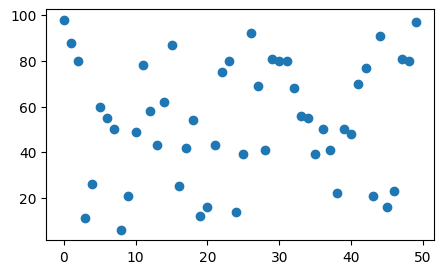

In [2]:
np.random.seed(613)
x = np.arange(50)
y = np.random.randint(0, 100, 50)
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(x, y)


<BarContainer object of 50 artists>

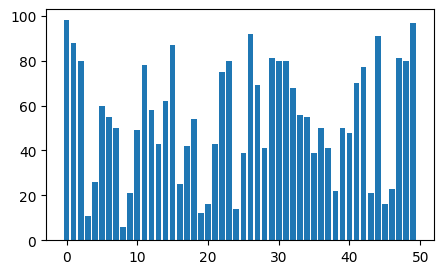

In [4]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(x, y)

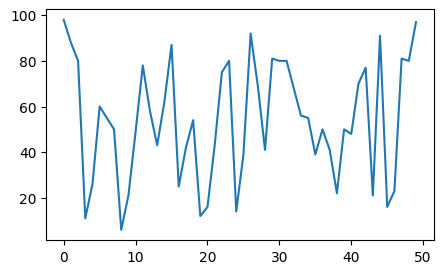

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y)


(array([4., 6., 2., 5., 7., 6., 4., 3., 9., 4.]),
 array([ 6. , 15.2, 24.4, 33.6, 42.8, 52. , 61.2, 70.4, 79.6, 88.8, 98. ]),
 <BarContainer object of 10 artists>)

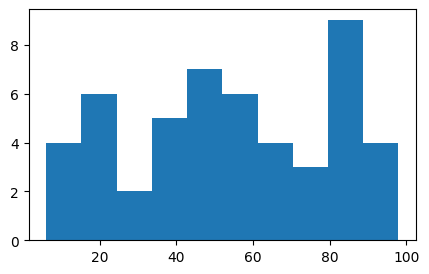

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(y)

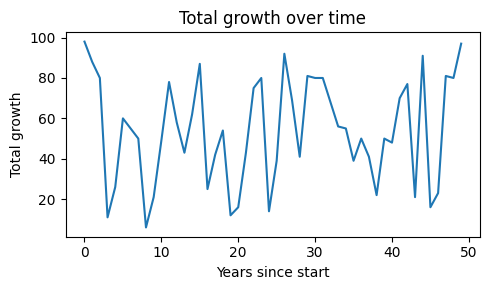

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y)
ax.set_title('Total growth over time')
ax.set_ylabel('Total growth')
ax.set_xlabel('Years since start')
fig.tight_layout()


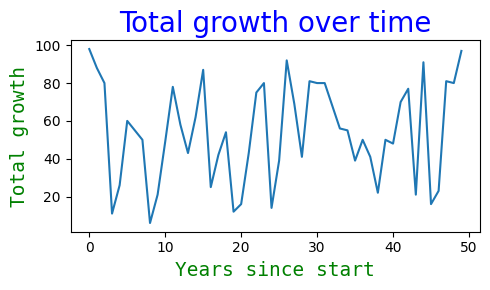

In [10]:
font1 = {'family': 'sans-serif', 'color': 'blue', 'size': 20}
font2 = {'family': 'monospace', 'color': 'green', 'size': 14}

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y)
ax.set_title('Total growth over time', fontdict=font1)
ax.set_ylabel('Total growth', fontdict=font2)
ax.set_xlabel('Years since start', fontdict=font2)
fig.tight_layout()


C:\Users\AsusIran\AppData\Local\Temp\ipykernel_24976\2258460723.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


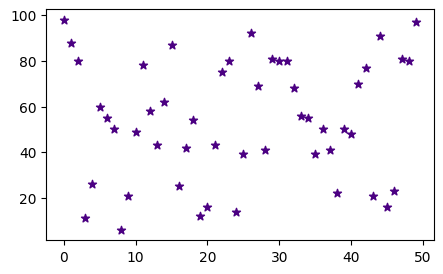

In [11]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(
    x,
    y,
    marker='*',      # NEW ADDITIONS
    color='indigo'   # NEW ADDITIONS
)

fig.show()


C:\Users\AsusIran\AppData\Local\Temp\ipykernel_24976\3958808740.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


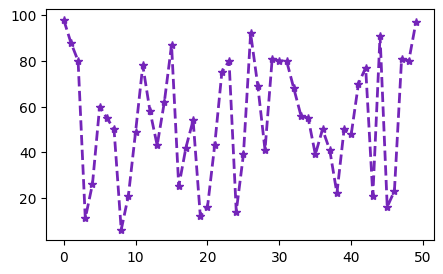

In [12]:
fig, ax = plt.subplots(figsize=(5, 3))

# color being the new addition
ax.plot(
    x,
    y,
    marker='*',
    color='#7425b9',
    linestyle='--',
    linewidth=2
)

fig.show()


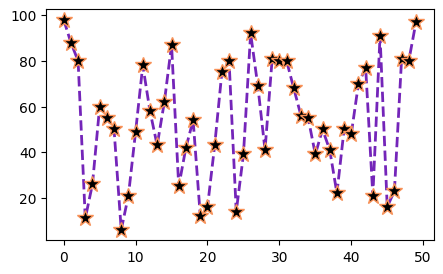

In [14]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(
    x,
    y,
    marker='*',
    markersize=12,        # NEW ADDITIONS
    color='#7425b9',
    linestyle='--',
    linewidth=2,
    markeredgecolor='#fa9359',   # NEW ADDITIONS
    markerfacecolor='#000000'    # NEW ADDITIONS
)


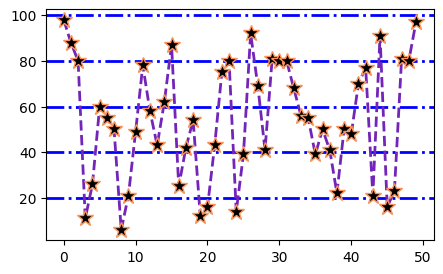

In [19]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(
    x,
    y,
    marker='*',
    markersize=12,        # NEW ADDITIONS
    color='#7425b9',
    linestyle='--',
    linewidth=2,
    markeredgecolor='#fa9359',   # NEW ADDITIONS
    markerfacecolor='#000000'    # NEW ADDITIONS
)
ax.grid(axis='y')

ax.grid(
    axis='y',
    color='blue',
    linewidth=2,
    linestyle='-.'
)


Activity of page 31:

Visualization choice: https://python-graph-gallery.com/ridgeline-graph-seaborn/


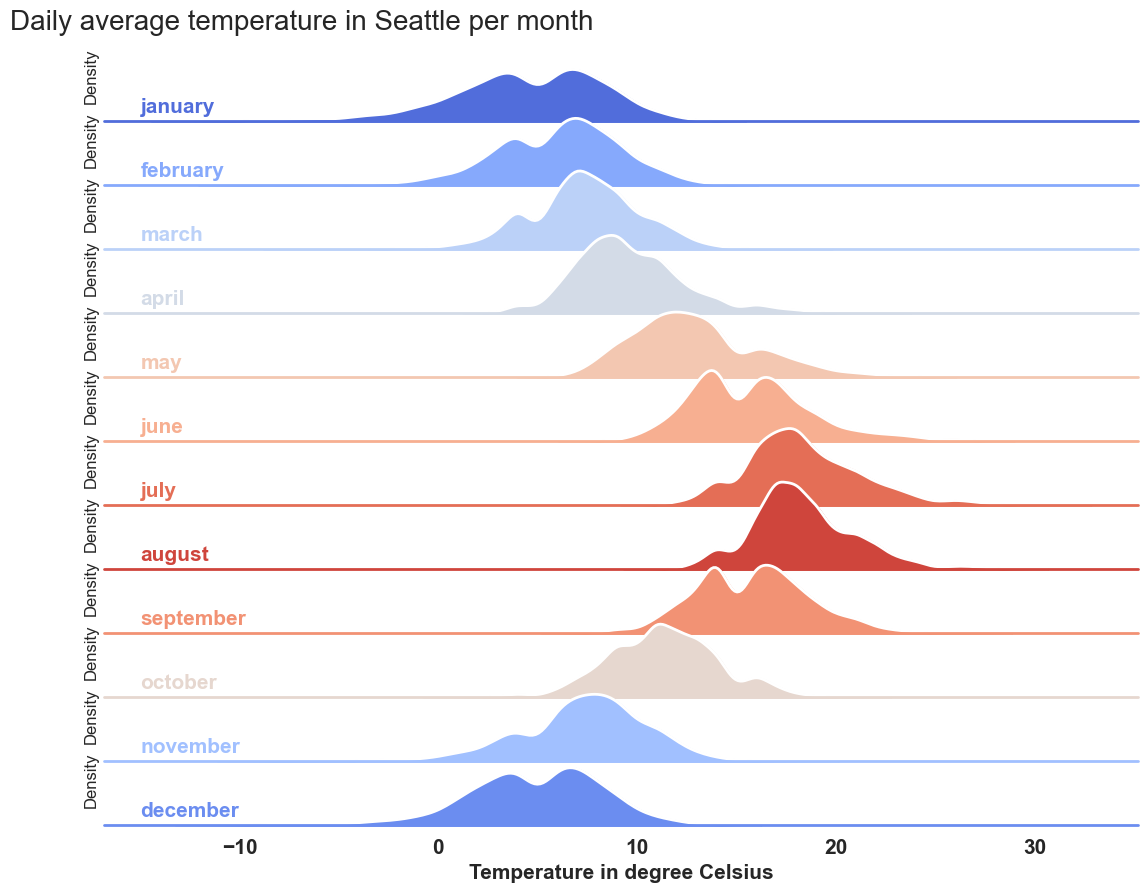

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Get the data (Seattle weather)
temp = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/2016-weather-data-seattle.csv")
temp["month"] = pd.to_datetime(temp["Date"]).dt.month

month_dict = {
    1: "january", 2: "february", 3: "march", 4: "april",
    5: "may", 6: "june", 7: "july", 8: "august",
    9: "september", 10: "october", 11: "november", 12: "december"
}
temp["month"] = temp["month"].map(month_dict)

# Mean temperature per month (used for coloring)
month_mean_serie = temp.groupby("month")["Mean_TemperatureC"].mean()
temp["mean_month"] = temp["month"].map(month_mean_serie)

# Color palette + FacetGrid
pal = sns.color_palette(palette="coolwarm", n_colors=12)
g = sns.FacetGrid(
    temp, row="month", hue="mean_month",
    aspect=15, height=0.75, palette=pal
)

# KDE layers
g.map(sns.kdeplot, "Mean_TemperatureC",
      bw_adjust=1, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "Mean_TemperatureC",
      bw_adjust=1, clip_on=False, color="w", lw=2)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Month labels
for i, ax in enumerate(g.axes.flat):
    ax.text(-15, 0.02, month_dict[i+1],
            fontweight="bold", fontsize=15,
            color=ax.lines[-1].get_color())

g.fig.subplots_adjust(hspace=-0.3)

# Clean up axes
g.set_titles("")
g.set(yticks=[])
g.despine(bottom=True, left=True)

plt.setp(ax.get_xticklabels(), fontsize=15, fontweight="bold")
plt.xlabel("Temperature in degree Celsius", fontweight="bold", fontsize=15)

g.fig.suptitle("Daily average temperature in Seattle per month",
               ha="right", fontsize=20, fontweight=20)

plt.show()

Aesthetic: Looks clean and professional; stacked curves + smooth shapes make it visually appealing, and the gradient color palette adds interest.

Substantive: Good for comparing distributions across months (not just averages), so it tells a richer story about seasonality.

Perceptual: Mostly clear for pattern-finding, but exact numeric comparisons are harder because curves overlap and the y-axis isn’t meaningful.